In [67]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('../data/processed/orders_full.csv')

In [3]:
df_entregues = pd.read_csv('../data/processed/orders_delivered.csv')

In [12]:
def calcular_somas_agrupadas(dataframe, coluna_agrupada, coluna_soma, nome_coluna_resultado, qnt_linhas=None):
    analise = (dataframe.groupby(coluna_agrupada)[coluna_soma].count()
        .reset_index(name=nome_coluna_resultado)
        .sort_values(by=nome_coluna_resultado, ascending=False)
        
        )
    if qnt_linhas is not None: 
        analise = analise.head(qnt_linhas)

    return analise


In [15]:
def calcular_medias_agrupada(dataframe, coluna_agrupada, coluna_media, nome_coluna_resultado, qnt_linhas=None):
    analise = (dataframe.groupby(coluna_agrupada)[coluna_media].mean().round(2)
        .reset_index(name=nome_coluna_resultado)
        .sort_values(by=nome_coluna_resultado, ascending=False)
    )
    if qnt_linhas is not None: 
        analise = analise.head(qnt_linhas)

       
    return analise

Qual estado tem mais pedidos?

In [34]:
estado_mais_pedidos = calcular_somas_agrupadas(df,'customer_state', 'order_id', 'pedidos', 1)

estado_mais_pedidos


,customer_state,pedidos
25,SP,47449


In [35]:
pedidos_por_estado = calcular_somas_agrupadas(df,'customer_state', 'order_id', 'pedidos')

pedidos_por_estado

,customer_state,pedidos
25,SP,47449
18,RJ,14579
10,MG,13129
22,RS,6235
17,PR,5740
23,SC,4176
4,BA,3799
6,DF,2406
8,GO,2333
7,ES,2256


Qual categoria de produto é mais vendida?

In [16]:


categoria_mais_vendida = calcular_somas_agrupadas(df,'product_category_name', 'order_id','quantidade_vendidas', 1)
categoria_mais_vendida

,product_category_name,quantidade_vendidas
13,cama_mesa_banho,11115


Qual período do ano tem mais pedidos?

In [20]:


mes_com_mais_vendas = calcular_somas_agrupadas(df,'order_month', 'order_id','vendas', 1)
mes_com_mais_vendas.style.hide(axis="index")

order_month,vendas
8,12158


In [21]:

forma_pagamento = calcular_somas_agrupadas(df, 'payment_type', 'order_id', 'qnt_pagamentos', 1)
forma_pagamento

,payment_type,qnt_pagamentos
1,credit_card,86017


Qual é o ticket médio geral?

In [22]:
total_pedidos = df['order_id'].nunique()
total_pedidos

pedidos_unicos = df.drop_duplicates(subset='order_id').copy()

ticket_medio_geral = round(pedidos_unicos['payment_value'].mean(), 2)
ticket_medio_geral


np.float64(160.61)

In [25]:
ticket_estado = calcular_medias_agrupada(pedidos_unicos, 'customer_state', 'payment_value', 'ticket_medio', 1)
ticket_estado.style.hide(axis="index").format({'ticket_medio': '{:.2f}'})

customer_state,ticket_medio
PB,265.01


Qual forma de pagamento é mais usada?

In [28]:
ticket_categoria = calcular_medias_agrupada(pedidos_unicos, 'product_category_name', 'payment_value','ticket_medio', 1)
ticket_categoria

,product_category_name,ticket_medio
61,pcs,1285.52


 O tempo de entrega impacta a avaliação do cliente?

In [30]:
df_analise_satisfacao = df_entregues.drop_duplicates(subset='order_id').copy()

In [32]:
tempo_entrega = calcular_medias_agrupada(df_analise_satisfacao, 'review_score', 'time_delivered', 'tempo_medio_dias', 1)
tempo_entrega.style.hide(axis="index").format({"tempo_medio_dias": '{:.2f}'})

review_score,tempo_medio_dias
3.333333,23.00


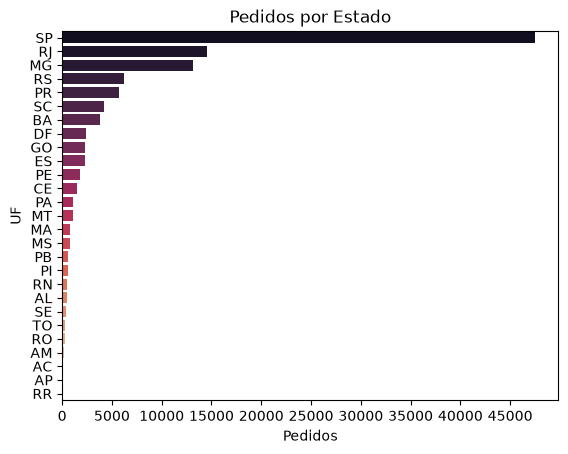

In [71]:

sns.barplot(data= pedidos_por_estado, y= 'customer_state', x= 'pedidos', palette='rocket', hue='customer_state')

plt.title('Pedidos por Estado')
plt.ylabel('UF')
plt.xlabel('Pedidos')

plt.xticks(np.arange(0, 50000, 5000))

plt.show()